Este cuaderno carga los modelos entrenados previamente para realizar una evaluación comparativa detallada utilizando reportes de clasificación y la visualización de matrices de confusión.

================ METRICAS: REGRESIÓN LOGÍSTICA ================
                precision    recall  f1-score   support

Regular Season       0.88      0.82      0.85      1222
      Playoffs       0.63      0.73      0.68       514

      accuracy                           0.79      1736
     macro avg       0.75      0.77      0.76      1736
  weighted avg       0.80      0.79      0.80      1736


================ METRICAS: ÁRBOL DE DECISIÓN BASE ================
                precision    recall  f1-score   support

Regular Season       0.83      0.83      0.83      1222
      Playoffs       0.60      0.61      0.60       514

      accuracy                           0.77      1736
     macro avg       0.72      0.72      0.72      1736
  weighted avg       0.77      0.77      0.77      1736



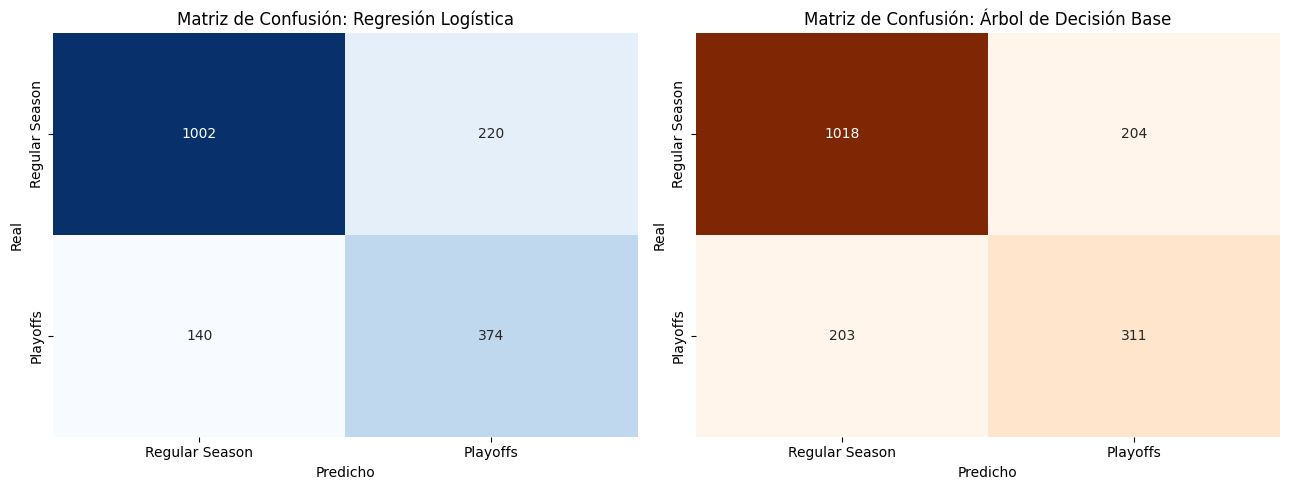

In [3]:
# Celda 1: Importación de librerías de evaluación
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Celda 2: Carga de particiones y modelos base
X_train_scaled, X_test_scaled, y_train, y_test = joblib.load('data_partitions.pkl')
log_reg = joblib.load('model_log_reg_base.pkl')
dt_base = joblib.load('model_dt_base.pkl')

# Celda 3: Generación de predicciones
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_dt = dt_base.predict(X_test_scaled)

# Celda 4: Reportes de Clasificación (Métricas Precision, Recall, F1-Score)
target_names = ['Regular Season', 'Playoffs']

print("================ METRICAS: REGRESIÓN LOGÍSTICA ================")
print(classification_report(y_test, y_pred_log, target_names=target_names))

print("\n================ METRICAS: ÁRBOL DE DECISIÓN BASE ================")
print(classification_report(y_test, y_pred_dt, target_names=target_names))

# Celda 5: Visualización Comparativa de Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz Regresión Logística
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión: Regresión Logística')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')
axes[0].set_xticklabels(target_names)
axes[0].set_yticklabels(target_names)

# Matriz Árbol de Decisión
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión: Árbol de Decisión Base')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')
axes[1].set_xticklabels(target_names)
axes[1].set_yticklabels(target_names)

plt.tight_layout()
plt.show()